# 수출 모멘텀 vs 주가 수익률: 리드-래그(선행-동행) 분석

**목적**: 특정 HS 코드(들)의 수출 YoY 성장률 및 그 가속도(모멘텀 변화)가,
향후 특정 종목의 주가 수익률(1개월/3개월/6개월)에 선행하는 관계가 있는지 확인합니다.

- 설명변수(X): HS 코드 조합의 월별 수출 YoY 성장률(%), YoY 가속도(%p)
- 종속변수(Y): 지정 티커의 향후 1/3/6개월 누적 주가 수익률(%)
- 분석 대상 기간에 대해서는 **실적(actual) 수출 데이터만 사용**합니다 (예측치는 아직 실현되지 않은 값이라
  향후 주가와 사후적으로 비교할 수 없으므로 backtest에서 제외합니다).
- ⚠️ 상관관계/회귀 결과는 **인과관계를 증명하지 않습니다**. 표본 수가 적을 수 있고,
  여러 조합을 동시에 검정하면 우연히 유의해 보이는 결과가 나올 수 있으니 참고용으로만 활용하세요.


## ① 환경 설정 및 DB 연결

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import os
import sys
import socket
import time
import subprocess
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pymysql
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# DATA 모듈 자동 탐색 (작업 디렉토리가 달라도 동작하도록)
# ------------------------------------------------------------
def _find_project_root(module_name: str = "DATA", max_up: int = 6):
    here = Path.cwd()
    for base in [here] + list(here.parents)[:max_up]:
        if (base / module_name).is_dir():
            return base
    return None

try:
    from DATA.stock_invest_function import *
except ModuleNotFoundError:
    _root = _find_project_root("DATA")
    if _root is None:
        raise ModuleNotFoundError("DATA 패키지를 찾을 수 없습니다. 프로젝트 루트에서 실행해 주세요.")
    sys.path.insert(0, str(_root))
    from DATA.stock_invest_function import *

# ------------------------------------------------------------
# 한글 폰트 자동 선택
# ------------------------------------------------------------
def _pick_korean_font() -> str:
    system = platform.system()
    candidates = {
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Darwin":  ["AppleGothic", "NanumGothic"],
        "Linux":   ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"],
    }.get(system, ["DejaVu Sans"])
    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return "DejaVu Sans"

matplotlib.rc('font', family=_pick_korean_font())
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# 어디서나(집/외부) 접속 가능한 DB host 자동 탐색
#   - 내부 IP(192.168.0.230)를 먼저 시도, 안 되면 외부 DDNS로 자동 전환
# ------------------------------------------------------------
DB_HOST_LAN  = "192.168.0.230"
DB_HOST_DDNS = "hystox74.synology.me"
DB_PORT = 3307


def _candidate_hosts() -> list:
    cands = [os.environ.get("DB_HOST_OVERRIDE"), DB_HOST_LAN, DB_HOST_DDNS]
    seen, out = set(), []
    for h in cands:
        if h and h not in seen:
            seen.add(h)
            out.append(h)
    return out


def _is_reachable(host: str, port: int, timeout: float = 1.5) -> bool:
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except OSError:
        return False


def resolve_db_host(port: int = DB_PORT, timeout: float = 1.5) -> str:
    print("[DB 접속] 접속 가능한 host 탐색 중...")
    for host in _candidate_hosts():
        t0 = time.time()
        ok = _is_reachable(host, port, timeout)
        print(f"   - {host}:{port}  {'연결됨' if ok else '실패'}  ({time.time() - t0:.1f}s)")
        if ok:
            return host
    raise ConnectionError("192.168.0.230(내부), hystox74.synology.me(외부) 모두 연결할 수 없습니다.")


db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': resolve_db_host(),
    'port': DB_PORT,
    'database': 'investar',
}


def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(url, pool_pre_ping=True, pool_recycle=1800,
                          connect_args={"connect_timeout": 10, "read_timeout": 60, "write_timeout": 60})


engine = make_engine(db_info)
TABLE_NAME = "korea_monthly_trade_forecast_v2"
print("DB 연결 완료:", db_info['host'])


# ------------------------------------------------------------
# 필요 패키지 자동 설치 헬퍼 (주가 라이브러리용)
# ------------------------------------------------------------
def _ensure_package(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        return __import__(import_name)
    except ImportError:
        print(f"[설치] '{pip_name}' 패키지가 없어 설치를 시도합니다...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "--quiet"])
        return __import__(import_name)


# ------------------------------------------------------------
# pivot_dataframe: 원본 노트북에서 로컬로 정의되어 있던 헬퍼 함수
#   (DATA.stock_invest_function 모듈이 아니라 노트북 셀에 직접 정의돼 있었으므로 여기 옮겨옵니다)
# ------------------------------------------------------------
def pivot_dataframe(df, index_col='date', column_col='root_hs_code',
                     indicator_col='indicator', value_col='value', indicator_value='expDlr'):
    """
    주어진 DataFrame에서 특정 indicator 값에 해당하는 데이터를 필터링하여 pivot table을 생성합니다.
    """
    filtered_df = df[df[indicator_col] == indicator_value].copy()
    pivot_df = filtered_df.pivot(index=index_col, columns=column_col, values=value_col)
    return pivot_df


[DB 접속] 접속 가능한 host 탐색 중...
   - 192.168.0.230:3307  실패  (1.5s)
   - hystox74.synology.me:3307  연결됨  (0.4s)
DB 연결 완료: hystox74.synology.me


## ② 사용자 입력 — 여기만 수정하면 됩니다

In [9]:
# ============================================================
# ★ 사용자 입력 ★
# ============================================================
HSCODE_LIST = ["854232"]          # 분석할 HS 코드 (여러 개면 합산 — 예: ["854232", "852351"])
INDICATOR   = "ensemble_expDlr"   # (참고용, 이 노트북에서는 실적만 사용하므로 직접 쓰이진 않음)

TICKER   = "000660"    # 분석할 종목 코드
MARKET   = "KR"         # "KR" (한국, FinanceDataReader) 또는 "US" (미국, yfinance)
TICKER_NAME = "삼성전자"  # 표시용 이름 (선택)

YEARS_STOCK = 10        # 주가 수집 기간(최근 n년)

HORIZONS = {1: "1개월(월간)", 3: "3개월(분기)", 6: "6개월(반기)"}   # 향후 수익률 측정 기간(개월)
SCATTER_XVAR = "export_yoy_accel(%p)"   # 산점도 대표 X변수 (또는 "export_yoy(%)")
SCATTER_H = 3                            # 산점도 대표 예측기간(개월)
# ============================================================

print(f"HS 코드: {HSCODE_LIST}  |  종목: {TICKER}({TICKER_NAME}, {MARKET})  |  주가 기간: 최근 {YEARS_STOCK}년")


HS 코드: ['854232']  |  종목: 000660(삼성전자, KR)  |  주가 기간: 최근 10년


## ③ 수출 모멘텀(YoY, YoY 가속도) 데이터프레임

In [10]:
def get_export_momentum_df(engine, db_info, hscode_list, table_name: str = "korea_monthly_trade_data") -> pd.DataFrame:
    """
    hscode_list에 포함된 HS 코드들의 수출액(실적)을 합산한 뒤,
    YoY 성장률(%)과 YoY 가속도(%p, YoY의 전월대비 차분)를 계산해서 반환합니다.
    실적(actual) 데이터만 사용합니다 (예측치는 backtest에 부적합하므로 제외).
    """
    trade_data_df = fetch_table_data(db_info, table_name)
    hist = pivot_dataframe(
        trade_data_df,
        index_col='date', column_col='root_hs_code',
        indicator_col='indicator', value_col='value',
        indicator_value='expDlr'
    )
    hist.index = pd.to_datetime(hist.index)
    hist = hist.sort_index()
    hist.columns = hist.columns.astype(str)

    missing = [h for h in hscode_list if h not in hist.columns]
    if missing:
        print(f"[경고] 다음 HS 코드는 데이터가 없어 제외됩니다: {missing}")
    present = [h for h in hscode_list if h in hist.columns]
    if not present:
        raise ValueError("유효한 HS 코드가 하나도 없습니다.")

    composite = hist[present].sum(axis=1, skipna=True)
    composite.name = "export_value"

    df = composite.to_frame()
    df["export_yoy(%)"] = df["export_value"].pct_change(12) * 100
    df["export_yoy_accel(%p)"] = df["export_yoy(%)"].diff(1)
    df["month"] = df.index.to_period("M")
    return df


export_df = get_export_momentum_df(engine, db_info, HSCODE_LIST)
print(f"수출 모멘텀 데이터프레임 shape: {export_df.shape}  (기간: {export_df.index.min().date()} ~ {export_df.index.max().date()})")
display(export_df.tail(10).round(2))


✅ 'korea_monthly_trade_data' 테이블에서 1428902건의 데이터를 가져왔습니다.
수출 모멘텀 데이터프레임 shape: (234, 4)  (기간: 2007-01-31 ~ 2026-06-30)


,export_value,export_yoy(%),export_yoy_accel(%p),month
date,,,,
2025-09-30,9.339170e+09,34.84,-6.09,2025-09
2025-10-31,8.886150e+09,42.85,8.01,2025-10
2025-11-30,1.016270e+10,57.72,14.87,2025-11
2025-12-31,1.263680e+10,69.75,12.04,2025-12
2026-01-31,1.211280e+10,154.14,84.39,2026-01
2026-02-28,1.581400e+10,234.62,80.48,2026-02
2026-03-31,2.075750e+10,210.08,-24.54,2026-03
2026-04-30,2.082910e+10,261.55,51.47,2026-04
2026-05-31,2.495060e+10,240.05,-21.50,2026-05


## ④ 주가 데이터 수집 (미국: yfinance / 한국: FinanceDataReader) → 월별 종가·수익률

In [11]:
def get_stock_monthly_df(ticker: str, market: str = "US", years: int = 10) -> pd.DataFrame:
    """
    market='US'  -> yfinance 사용
    market='KR'  -> FinanceDataReader 사용 (ticker는 'A005930' 또는 '005930' 형태 모두 지원)
    반환: index=월말 날짜, columns=[close, monthly_return(%), month(Period)]
    """
    end = pd.Timestamp.today()
    start = end - pd.DateOffset(years=years)

    if market.upper() == "US":
        yf = _ensure_package("yfinance")
        raw = yf.download(ticker, start=start.strftime("%Y-%m-%d"), end=end.strftime("%Y-%m-%d"),
                           progress=False, auto_adjust=True)
        if raw.empty:
            raise ValueError(f"yfinance에서 {ticker} 데이터를 가져오지 못했습니다.")
        close = raw["Close"]
        if isinstance(close, pd.DataFrame):   # 일부 yfinance 버전은 MultiIndex 컬럼 반환
            close = close.iloc[:, 0]

    elif market.upper() == "KR":
        fdr = _ensure_package("FinanceDataReader", "finance-datareader")
        kr_ticker = ticker[1:] if ticker.upper().startswith("A") and ticker[1:].isdigit() else ticker
        raw = fdr.DataReader(kr_ticker, start.strftime("%Y-%m-%d"), end.strftime("%Y-%m-%d"))
        if raw.empty:
            raise ValueError(f"FinanceDataReader에서 {ticker} 데이터를 가져오지 못했습니다.")
        close = raw["Close"]

    else:
        raise ValueError("MARKET은 'US' 또는 'KR'이어야 합니다.")

    close.index = pd.to_datetime(close.index)
    monthly_close = close.resample("M").last().dropna()
    monthly_return = monthly_close.pct_change() * 100

    df = pd.DataFrame({"close": monthly_close, "monthly_return(%)": monthly_return})
    df["month"] = df.index.to_period("M")
    return df


stock_df = get_stock_monthly_df(TICKER, MARKET, YEARS_STOCK)
print(f"주가 데이터프레임 shape: {stock_df.shape}  (기간: {stock_df.index.min().date()} ~ {stock_df.index.max().date()})")
display(stock_df.tail(10).round(2))


주가 데이터프레임 shape: (121, 3)  (기간: 2016-07-31 ~ 2026-07-31)


,close,monthly_return(%),month
Date,,,
2025-10-31,559000,60.86,2025-10
2025-11-30,530000,-5.19,2025-11
2025-12-31,651000,22.83,2025-12
2026-01-31,909000,39.63,2026-01
2026-02-28,1061000,16.72,2026-02
2026-03-31,807000,-23.94,2026-03
2026-04-30,1286000,59.36,2026-04
2026-05-31,2333000,81.42,2026-05
2026-06-30,2650000,13.59,2026-06


## ⑤ 수출 모멘텀 + 주가 데이터 결합

In [12]:
combined_df = pd.merge(
    export_df.reset_index().rename(columns={export_df.index.name or "index": "date"}),
    stock_df.reset_index()[["month", "close", "monthly_return(%)"]],
    on="month", how="inner"
).set_index("date").sort_index()

print(f"통합 데이터프레임 shape: {combined_df.shape}")
if combined_df.empty:
    print("[경고] 두 데이터의 겹치는 기간이 없습니다. HS 코드/기간/티커를 확인하세요.")
display(combined_df.tail(15).round(2))


통합 데이터프레임 shape: (120, 6)


,export_value,export_yoy(%),export_yoy_accel(%p),month,close,monthly_return(%)
date,,,,,,
2025-04-30,5.761090e+09,17.65,1.54,2025-04,177500,-6.92
2025-05-31,7.337390e+09,28.40,10.75,2025-05,204500,15.21
2025-06-30,8.230270e+09,16.66,-11.74,2025-06,292000,42.79
2025-07-31,7.568270e+09,30.39,13.73,2025-07,273500,-6.34
2025-08-31,8.504650e+09,40.92,10.54,2025-08,269000,-1.65
2025-09-30,9.339170e+09,34.84,-6.09,2025-09,347500,29.18
2025-10-31,8.886150e+09,42.85,8.01,2025-10,559000,60.86
2025-11-30,1.016270e+10,57.72,14.87,2025-11,530000,-5.19
2025-12-31,1.263680e+10,69.75,12.04,2025-12,651000,22.83


## ⑥ 리드-래그 분석: 수출 모멘텀(t) → 향후 1/3/6개월 주가 수익률


[리드-래그 분석 요약] 수출 모멘텀 → 향후 주가 수익률


,설명변수,예측기간,n,상관계수(r),R^2,기울기(slope),p-value
0,수출 YoY 성장률(레벨),1개월(월간),119,0.2835,0.0804,0.0728,0.0018
1,수출 YoY 성장률(레벨),3개월(분기),117,0.3643,0.1327,0.2294,0.0001
2,수출 YoY 성장률(레벨),6개월(반기),114,0.0713,0.0051,0.1035,0.4508
3,수출 YoY 가속도(모멘텀 변화),1개월(월간),119,0.0685,0.0047,0.0558,0.4589
4,수출 YoY 가속도(모멘텀 변화),3개월(분기),117,0.1624,0.0264,0.2932,0.0802
5,수출 YoY 가속도(모멘텀 변화),6개월(반기),114,0.2008,0.0403,0.8722,0.0321


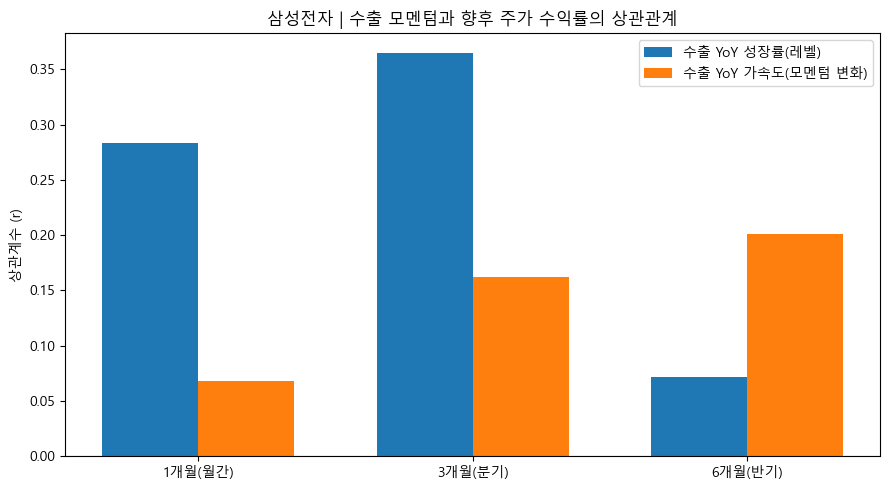

In [13]:
_ensure_package("scipy")
from scipy import stats as _stats

def add_forward_returns(df: pd.DataFrame, price_col: str = "close", horizons: dict = HORIZONS) -> pd.DataFrame:
    """각 시점 t 기준, 향후 h개월 누적 수익률(%)을 계산해 컬럼으로 추가."""
    out = df.copy()
    for h in horizons:
        out[f"fwd_return_{h}m(%)"] = (out[price_col].shift(-h) / out[price_col] - 1) * 100
    return out

combined_df = add_forward_returns(combined_df, horizons=HORIZONS)

EXPLAIN_VARS = {
    "export_yoy(%)": "수출 YoY 성장률(레벨)",
    "export_yoy_accel(%p)": "수출 YoY 가속도(모멘텀 변화)",
}

results = []
for xcol, xlabel in EXPLAIN_VARS.items():
    for h, hlabel in HORIZONS.items():
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 10:
            print(f"[건너뜀] {xlabel} → {hlabel}: 표본 수 부족 (n={len(sub)})")
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        results.append({
            "설명변수": xlabel, "예측기간": hlabel, "n": len(sub),
            "상관계수(r)": round(r, 4), "R^2": round(r**2, 4),
            "기울기(slope)": round(slope, 4), "p-value": round(p, 4),
        })

reg_summary = pd.DataFrame(results)
print("\n[리드-래그 분석 요약] 수출 모멘텀 → 향후 주가 수익률")
display(reg_summary)

# ---- 막대차트: 예측기간별 상관계수 비교 ----
fig, ax = plt.subplots(figsize=(9, 5))
width = 0.35
x = np.arange(len(HORIZONS))
for i, (xcol, xlabel) in enumerate(EXPLAIN_VARS.items()):
    vals = []
    for h, hlabel in HORIZONS.items():
        row = reg_summary[(reg_summary["설명변수"] == xlabel) & (reg_summary["예측기간"] == hlabel)]
        vals.append(row["상관계수(r)"].values[0] if len(row) else np.nan)
    ax.bar(x + i * width, vals, width, label=xlabel)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(list(HORIZONS.values()))
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("상관계수 (r)")
ax.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀과 향후 주가 수익률의 상관관계")
ax.legend()
plt.tight_layout()
plt.show()


## ⑦ 산점도 + 회귀선 (전체 조합)

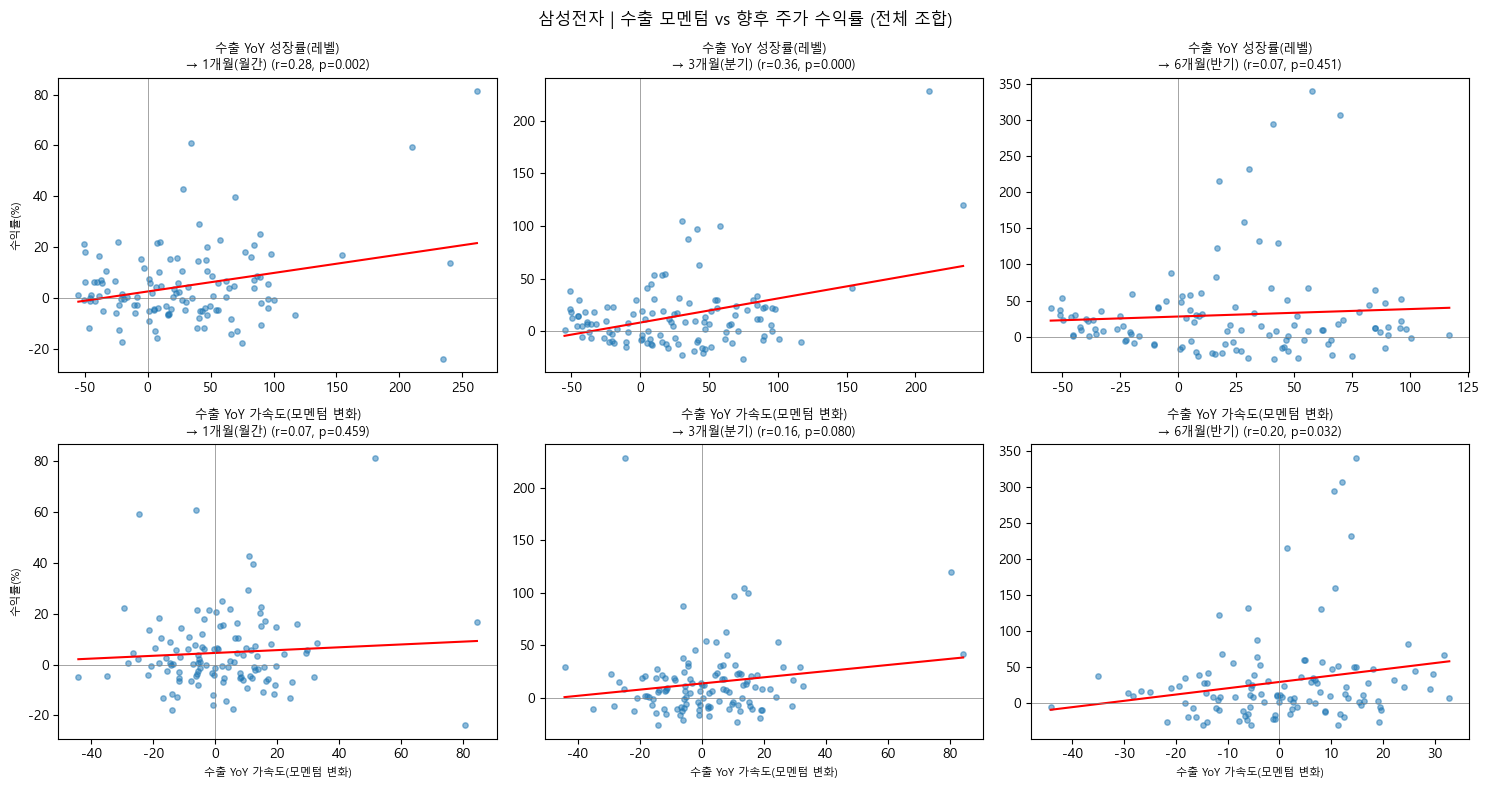

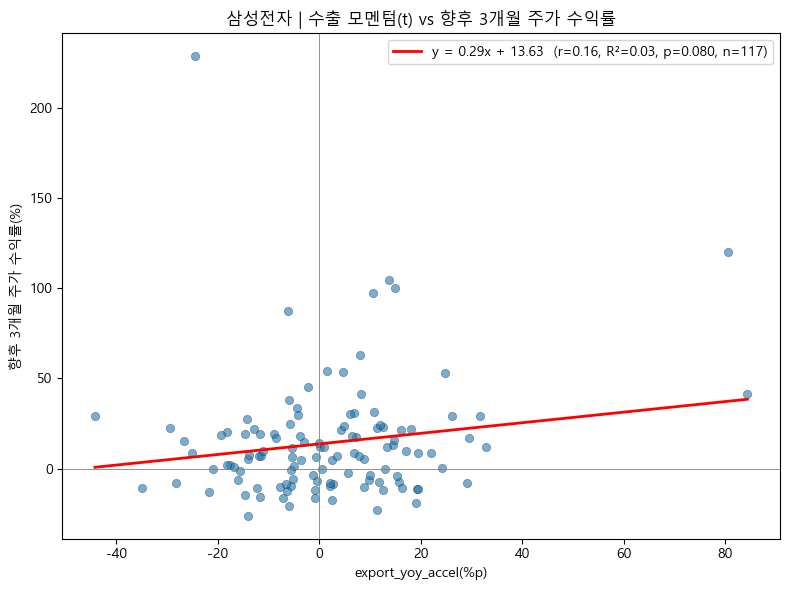

In [14]:
fig, axes = plt.subplots(len(EXPLAIN_VARS), len(HORIZONS), figsize=(15, 8))
if len(EXPLAIN_VARS) == 1:
    axes = axes.reshape(1, -1)

for i, (xcol, xlabel) in enumerate(EXPLAIN_VARS.items()):
    for j, (h, hlabel) in enumerate(HORIZONS.items()):
        ax = axes[i, j]
        ycol = f"fwd_return_{h}m(%)"
        sub = combined_df[[xcol, ycol]].dropna()
        if len(sub) < 5:
            ax.set_visible(False)
            continue
        slope, intercept, r, p, stderr = _stats.linregress(sub[xcol], sub[ycol])
        ax.scatter(sub[xcol], sub[ycol], alpha=0.5, s=15)
        xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 50)
        ax.plot(xs, intercept + slope * xs, color="red", linewidth=1.5)
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.set_title(f"{xlabel}\n→ {hlabel} (r={r:.2f}, p={p:.3f})", fontsize=9)
        if i == len(EXPLAIN_VARS) - 1:
            ax.set_xlabel(xlabel, fontsize=8)
        if j == 0:
            ax.set_ylabel("수익률(%)", fontsize=8)

plt.suptitle(f"{TICKER_NAME or TICKER} | 수출 모멘텀 vs 향후 주가 수익률 (전체 조합)")
plt.tight_layout()
plt.show()

# ---- 대표 산점도(SCATTER_XVAR, SCATTER_H) 확대 버전 ----
ycol = f"fwd_return_{SCATTER_H}m(%)"
sub = combined_df[[SCATTER_XVAR, ycol]].dropna()
if len(sub) >= 5:
    slope, intercept, r, p, stderr = _stats.linregress(sub[SCATTER_XVAR], sub[ycol])
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(sub[SCATTER_XVAR], sub[ycol], alpha=0.6, edgecolor="k", linewidth=0.3)
    xs = np.linspace(sub[SCATTER_XVAR].min(), sub[SCATTER_XVAR].max(), 50)
    ax.plot(xs, intercept + slope * xs, color="red", linewidth=2,
            label=f"y = {slope:.2f}x + {intercept:.2f}  (r={r:.2f}, R²={r**2:.2f}, p={p:.3f}, n={len(sub)})")
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_xlabel(SCATTER_XVAR)
    ax.set_ylabel(f"향후 {SCATTER_H}개월 주가 수익률(%)")
    ax.set_title(f"{TICKER_NAME or TICKER} | 수출 모멘텀(t) vs 향후 {SCATTER_H}개월 주가 수익률")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"[건너뜀] 대표 산점도: 표본 수 부족 (n={len(sub)})")


## ⑧ 시계열 동행성 시각화 (이중축)

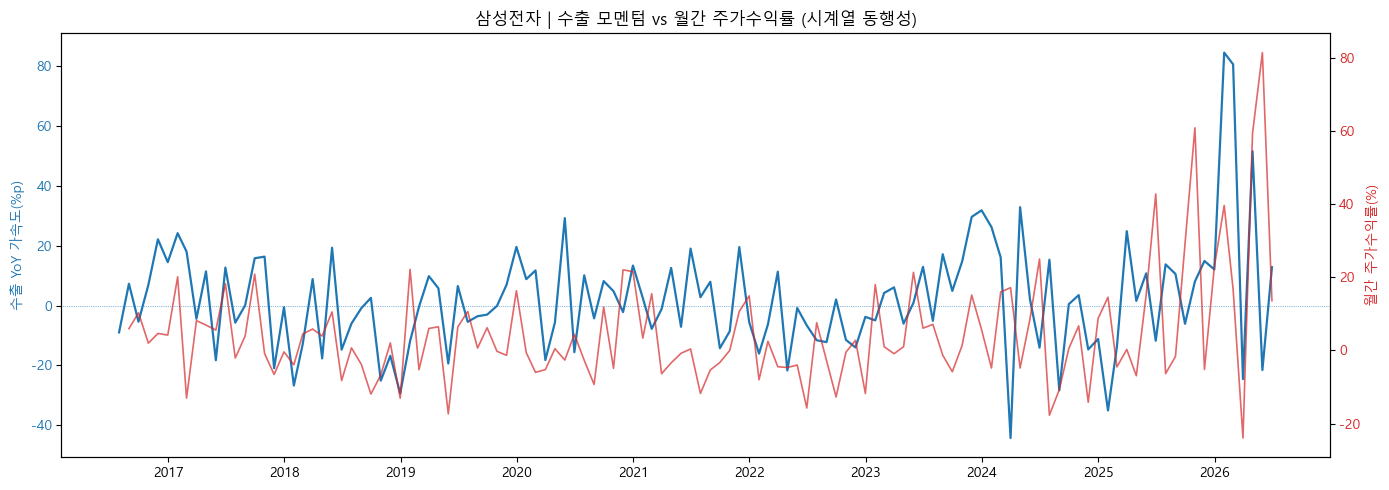


[참고] r>0 이면 수출 모멘텀이 강해질 때 향후 주가 수익률도 함께/뒤이어 상승하는 경향,
       r<0 이면 반대 방향(선반영 후 되돌림 등)일 가능성을 시사합니다.
       p-value가 0.05보다 크면 통계적으로 유의하다고 보기 어렵습니다 (표본 수 n도 함께 확인하세요).


In [15]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(combined_df.index, combined_df["export_yoy_accel(%p)"], color="#1f77b4", linewidth=1.6,
         label="수출 YoY 가속도(%p)")
ax1.axhline(0, color="#1f77b4", linewidth=0.5, linestyle=":")
ax1.set_ylabel("수출 YoY 가속도(%p)", color="#1f77b4")
ax1.tick_params(axis='y', labelcolor="#1f77b4")

ax2 = ax1.twinx()
ax2.plot(combined_df.index, combined_df["monthly_return(%)"], color="#d62728", alpha=0.7, linewidth=1.2,
         label="월간 주가수익률(%)")
ax2.set_ylabel("월간 주가수익률(%)", color="#d62728")
ax2.tick_params(axis='y', labelcolor="#d62728")

plt.title(f"{TICKER_NAME or TICKER} | 수출 모멘텀 vs 월간 주가수익률 (시계열 동행성)")
fig.tight_layout()
plt.show()

print("\n[참고] r>0 이면 수출 모멘텀이 강해질 때 향후 주가 수익률도 함께/뒤이어 상승하는 경향,")
print("       r<0 이면 반대 방향(선반영 후 되돌림 등)일 가능성을 시사합니다.")
print("       p-value가 0.05보다 크면 통계적으로 유의하다고 보기 어렵습니다 (표본 수 n도 함께 확인하세요).")
